In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
import seaborn as sns
import colorcet as cc

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (separate runs)
        idate = start_dates[ii]
        idirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(idirs) > 0:
            for dd in idirs:
                # Find track stats file
                fname = sorted(glob.glob(f'{dd}/{domain}/stats/{in_basename}*nc'))
                if len(fname) > 0:
                    files.append(fname[0])
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
lon_range = [-65., -64.]
lat_range = [-33.3, -30.8]
gridspacing_d2 = '2.5km'
gridspacing_d3 = '500m'
# gridspacing_d4 = '100m'

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
# files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4_15min')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
# wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4_15min')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

# print(f'Number of stats files (D4): {len(files_d4)}')
# print(f'Number of W files (D4): {len(wfiles_d4)}')

files_d2, files_d3, wfiles_d2, wfiles_d3, efiles_d2, efiles_d3

Number of stats files (D2): 13
Number of W files (D2): 13
Number of ENV files (D2): 13
Number of stats files (D3): 13
Number of W files (D3): 13
Number of ENV files (D3): 13


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs_en03/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs_en00/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs_en19/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs_en18/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs_en01/d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181219/eda_en09/d2/stats/trackstats_20181219.1200_20181220.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20190122/gefs_en01/d2/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20190125/gefs_en11/d2/stats/trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf/atm

## Read stats data

In [4]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 2481


<xarray.Dataset>
Dimensions:                  (tracks: 2481, times: 64, z: 29, core: 20,
                              height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 2477 2478 2479 2480
  * times                    (times) int64 -4 -3 -2 -1 0 1 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/89)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    CoreArea_down            (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    CoreMinW_down            (tracks, times, z, core) float32 dask.array<chunksize=(144, 64, 29, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(144,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       2.5

In [5]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 5923


<xarray.Dataset>
Dimensions:                  (tracks: 5923, times: 64, z: 29, core: 20,
                              height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 5919 5920 5921 5922
  * times                    (times) int64 -4 -3 -2 -1 0 1 ... 54 55 56 57 58 59
  * z                        (z) float64 500.0 1e+03 1.5e+03 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/89)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    CoreArea_down            (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    CoreMinW_down            (tracks, times, z, core) float32 dask.array<chunksize=(393, 64, 29, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(393,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

## Subset tracks that initiate near the SDC

In [6]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times')
maxlon_d2 = ds_d2['meanlon'].max(dim='times')
minlat_d2 = ds_d2['meanlat'].min(dim='times')
maxlat_d2 = ds_d2['meanlat'].max(dim='times')
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 1278


In [7]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times')
maxlon_d3 = ds_d3['meanlon'].max(dim='times')
minlat_d3 = ds_d3['meanlat'].min(dim='times')
maxlat_d3 = ds_d3['meanlat'].max(dim='times')
# Subset d3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 1686


In [8]:
ht_w_d2 = ds_d2['z']
ht_e_d2 = ds_d2['height']
time_res_d2 = ds_d2.attrs['time_resolution_hour']
pixel_radius_d2 = ds_d2.attrs['pixel_radius_km']
lifetime_d2 = ds_d2['track_duration'] * time_res_d2
time_res_d2 = ds_d2.attrs['time_resolution_hour']

end_merge_tracknumber_d2 = ds_d2['end_merge_tracknumber']
start_split_tracknumber_d2 = ds_d2['start_split_tracknumber']

In [9]:
ht_w_d3 = ds_d3['z']
ht_e_d3 = ds_d3['height']
time_res_d3 = ds_d3.attrs['time_resolution_hour']
pixel_radius_d3 = ds_d3.attrs['pixel_radius_km']
lifetime_d3 = ds_d3['track_duration'] * time_res_d3
time_res_d3 = ds_d3.attrs['time_resolution_hour']

end_merge_tracknumber_d3 = ds_d3['end_merge_tracknumber']
start_split_tracknumber_d3 = ds_d3['start_split_tracknumber']

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 129.,
          0.,  82.,  53.,  40.,  24.,  38.,  24.,   7.,  10.,  17.,   4.,
          9.,   0.,   2.,   2.,   0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7]),
 <BarContainer object of 27 artists>)

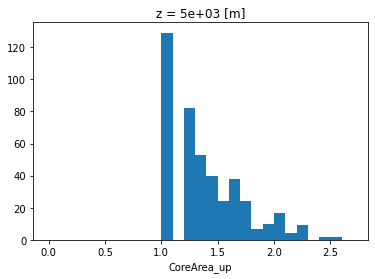

In [10]:
# Specify mid-level height [km] to quantify updrafts
Zmid = 5
# Zmid = 3

# Max updraft area over the cell lifetime and all updraft cores at a given height
MaxCoreAreaUp_Zmid_d2 = ds_d2['CoreArea_up'].max(dim=('times','core')).sel(z=Zmid*1000).load()
CoreAreaUp_bins = np.arange(0, 2.8, 0.1)
np.log10(MaxCoreAreaUp_Zmid_d2).plot.hist(bins=CoreAreaUp_bins)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


(array([133.,  75.,  77., 188., 101., 118., 157., 128.,  87.,  63.,  48.,
         39.,  28.,  22.,  25.,  19.,   7.,   9.,   2.,   6.,   3.,   3.,
          4.,   2.,   1.,   0.,   0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7]),
 <BarContainer object of 27 artists>)

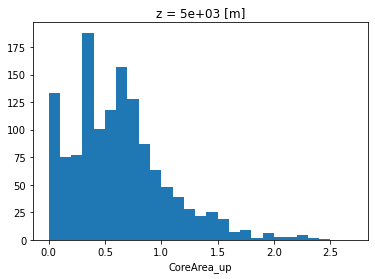

In [11]:
# Max updraft area over the cell lifetime and all updraft cores
MaxCoreAreaUp_Zmid_d3 = ds_d3['CoreArea_up'].max(dim=('times','core')).sel(z=Zmid*1000).load()
CoreAreaUp_bins = np.arange(0., 2.8, 0.1)
np.log10(MaxCoreAreaUp_Zmid_d3).plot.hist(bins=CoreAreaUp_bins)

In [12]:
# Median updraft core area
med_MaxCoreAreaUp_Zmid_d2 = np.nanmedian(MaxCoreAreaUp_Zmid_d2)
print(f'Median MaxCoreAreaUp (D2): {med_MaxCoreAreaUp_Zmid_d2:.02f} km^2')

med_MaxCoreAreaUp_Zmid_d3 = np.nanmedian(MaxCoreAreaUp_Zmid_d3)
print(f'Median MaxCoreAreaUp (D3): {med_MaxCoreAreaUp_Zmid_d3:.02f} km^2')

Median MaxCoreAreaUp (D2): 25.00 km^2
Median MaxCoreAreaUp (D3): 3.50 km^2


In [13]:
# Find updraft area percentile values
low_MaxCoreAreaUp_Zmid_d2 = np.nanquantile(MaxCoreAreaUp_Zmid_d2, 0.33)
hi_MaxCoreAreaUp_Zmid_d2 = np.nanquantile(MaxCoreAreaUp_Zmid_d2, 0.66)
print(f'[D2] Lower 1/3 MaxCoreAreaUp: {low_MaxCoreAreaUp_Zmid_d2}, Upper 1/3 MaxCoreAreaUp: {hi_MaxCoreAreaUp_Zmid_d2}')

[D2] Lower 1/3 MaxCoreAreaUp: 18.75, Upper 1/3 MaxCoreAreaUp: 31.25


In [14]:
# Find updraft area percentile values
low_MaxCoreAreaUp_Zmid_d3 = np.nanquantile(MaxCoreAreaUp_Zmid_d3, 0.33)
hi_MaxCoreAreaUp_Zmid_d3 = np.nanquantile(MaxCoreAreaUp_Zmid_d3, 0.66)
print(f'[D3] Lower 1/3 MaxCoreAreaUp: {low_MaxCoreAreaUp_Zmid_d3}, Upper 1/3 MaxCoreAreaUp: {hi_MaxCoreAreaUp_Zmid_d3}')

[D3] Lower 1/3 MaxCoreAreaUp: 2.25, Upper 1/3 MaxCoreAreaUp: 5.070000000000022


## Pick a pre-C time and height to calculate mean RH as a function of updraft width

In [84]:
Zmid_RH_d3 = 4.4  # [km]
Zmid_RH_d2 = 5.0  # [km]
TpreCI_d3 = -0.5  # [hour]
TpreCI_d2 = -0.5
rh_Zmid_d2 = ds_d2.rh.sel(times=int(TpreCI_d2/time_res_d2), height=Zmid_RH_d2*1000)
rh_Zmid_d3 = ds_d3.rh.sel(times=int(TpreCI_d3/time_res_d3), height=Zmid_RH_d3*1000)
rh_Zmid_d2.shape, rh_Zmid_d3.shape

((1278,), (1686,))

In [85]:
# Core area bins
CoreAreaUp_bins = np.arange(-0.5, 2.8, 0.1)
nbins = len(CoreAreaUp_bins)
# Core area bin center values
CoreAreaUp_bins_c = CoreAreaUp_bins[:-1] + np.diff(CoreAreaUp_bins)/2

min_ns = 5
rh_CoreArea_avg_d2 = np.full(nbins-1, np.nan, dtype=float)
rh_CoreArea_avg_d3 = np.full(nbins-1, np.nan, dtype=float)

for ii in range(nbins-1):
    idx_d2 = np.where((np.log10(MaxCoreAreaUp_Zmid_d2.data) >= CoreAreaUp_bins[ii]) & (np.log10(MaxCoreAreaUp_Zmid_d2.data) < CoreAreaUp_bins[ii+1]))[0]
    idx_d3 = np.where((np.log10(MaxCoreAreaUp_Zmid_d3.data) >= CoreAreaUp_bins[ii]) & (np.log10(MaxCoreAreaUp_Zmid_d3.data) < CoreAreaUp_bins[ii+1]))[0]
    # print(ii, len(idx))
    if len(idx_d2) > min_ns:
        rh_CoreArea_avg_d2[ii] = np.nanmean(rh_Zmid_d2[idx_d2])
    if len(idx_d3) > min_ns:
        rh_CoreArea_avg_d3[ii] = np.nanmean(rh_Zmid_d3[idx_d3])

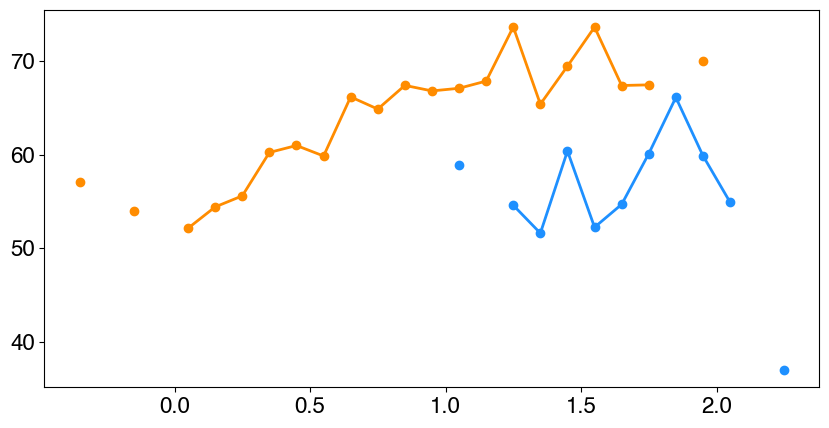

In [86]:
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'Helvetica'
colors = {'d2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
labels = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
lw = 2

fig, axes = plt.subplots(1, 1, figsize=[10,5], dpi=100)
ax = axes
ax.plot(CoreAreaUp_bins_c, rh_CoreArea_avg_d2, color=colors['d2'], marker='o', lw=lw, label=labels['d2'])
ax.plot(CoreAreaUp_bins_c, rh_CoreArea_avg_d3, color=colors['d3'], marker='o', lw=lw, label=labels['d3'])

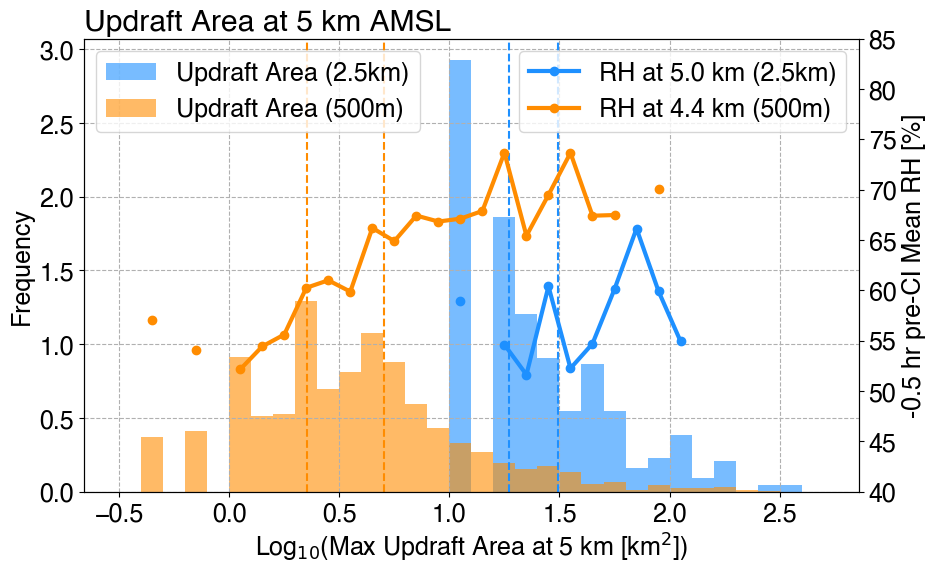

In [93]:
mpl.rcParams['font.size'] = 18
mpl.rcParams['font.family'] = 'Helvetica'
colors = {'d2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
labels = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
lw = 3

fig, axes = plt.subplots(1, 1, figsize=[10,6], dpi=100)
ax = axes
CoreAreaUp_bins = np.arange(-0.5, 2.8, 0.1)
ax.hist(np.log10(MaxCoreAreaUp_Zmid_d2.data), density=True, bins=CoreAreaUp_bins, color=colors['d2'], alpha=0.6, label=f"Updraft Area ({labels['d2']})")
ax.hist(np.log10(MaxCoreAreaUp_Zmid_d3.data), density=True, bins=CoreAreaUp_bins, color=colors['d3'], alpha=0.6, label=f"Updraft Area ({labels['d3']})")
ax.axvline(x=np.log10(low_MaxCoreAreaUp_Zmid_d2), color=colors['d2'], ls='--')
ax.axvline(x=np.log10(hi_MaxCoreAreaUp_Zmid_d2), color=colors['d2'], ls='--')
ax.axvline(x=np.log10(low_MaxCoreAreaUp_Zmid_d3), color=colors['d3'], ls='--')
ax.axvline(x=np.log10(hi_MaxCoreAreaUp_Zmid_d3), color=colors['d3'], ls='--')
ax.set_xlabel('Log$_{10}$'+f'(Max Updraft Area at {Zmid} km [km$^2$])')
ax.set_ylabel('Frequency')
ax.grid(ls='--')
ax.set_title(f'Updraft Area at {Zmid} km AMSL', loc='left')
ax.legend(loc='upper left')

ax1 = ax.twinx()
ax1.plot(CoreAreaUp_bins_c, rh_CoreArea_avg_d2, color=colors['d2'], marker='o', lw=lw, label=f"RH at {Zmid_RH_d2} km ({labels['d2']})")
ax1.plot(CoreAreaUp_bins_c, rh_CoreArea_avg_d3, color=colors['d3'], marker='o', lw=lw, label=f"RH at {Zmid_RH_d3} km ({labels['d3']})")
ax1.set_ylabel(f'{TpreCI_d2} hr pre-CI Mean RH [%]')
ax1.legend(loc='upper right')
ax1.set_ylim(40, 85)

figname = f'{figdir}MaxCoreAreaUp{Zmid}km_pdf_preCI_RH_{Zmid_RH}km_{TpreCI_d2}h.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

In [21]:
# Separate tracks with low/high MaxCoreAreaUp, exclude tracks that end as merger
l_idx_d2 = np.where(
    (MaxCoreAreaUp_Zmid_d2 <= low_MaxCoreAreaUp_Zmid_d2)
    & (np.isnan(end_merge_tracknumber_d2)) 
    & (np.isnan(start_split_tracknumber_d2))
)[0]
h_idx_d2 = np.where(
    (MaxCoreAreaUp_Zmid_d2 >= hi_MaxCoreAreaUp_Zmid_d2)
    & (np.isnan(end_merge_tracknumber_d2))
    & (np.isnan(start_split_tracknumber_d2))
)[0]
print(f'[D2] ntracks (low): {len(l_idx_d2)}, ntracks (high): {len(h_idx_d2)}')

[D2] ntracks (low): 60, ntracks (high): 43


In [22]:
# Separate tracks with low/high MaxCoreAreaUp, exclude tracks that end as merger
l_idx_d3 = np.where(
    (MaxCoreAreaUp_Zmid_d3 <= low_MaxCoreAreaUp_Zmid_d3)
    & (np.isnan(end_merge_tracknumber_d3)) 
    & (np.isnan(start_split_tracknumber_d3))
)[0]
h_idx_d3 = np.where(
    (MaxCoreAreaUp_Zmid_d3 >= hi_MaxCoreAreaUp_Zmid_d3)
    & (np.isnan(end_merge_tracknumber_d3))
    & (np.isnan(start_split_tracknumber_d3))
)[0]
print(f'[D3] ntracks (low): {len(l_idx_d3)}, ntracks (high): {len(h_idx_d3)}')

[D3] ntracks (low): 231, ntracks (high): 127


In [23]:
MaxCoreAreaUp_avg_l_d3 = ds_d3.CoreArea_up.isel(tracks=l_idx_d3).max(dim=('times','core')).mean(dim='tracks').load()
MaxCoreAreaUp_avg_h_d3 = ds_d3.CoreArea_up.isel(tracks=h_idx_d3).max(dim=('times','core')).mean(dim='tracks').load()

MaxMeanWUp_avg_l_d3 = ds_d3.CoreMeanW_up.isel(tracks=l_idx_d3).max(dim=('times','core')).mean(dim='tracks').load()
MaxMeanWUp_avg_h_d3 = ds_d3.CoreMeanW_up.isel(tracks=h_idx_d3).max(dim=('times','core')).mean(dim='tracks').load()

MaxMassFluxUp_avg_l_d3 = ds_d3.MassFlux_up.isel(tracks=l_idx_d3).max(dim=('times')).mean(dim='tracks').load()
MaxMassFluxUp_avg_h_d3 = ds_d3.MassFlux_up.isel(tracks=h_idx_d3).max(dim=('times')).mean(dim='tracks').load()

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [24]:
MaxCoreAreaUp_avg_l_d2 = ds_d2.CoreArea_up.isel(tracks=l_idx_d2).max(dim=('times','core')).mean(dim='tracks').load()
MaxCoreAreaUp_avg_h_d2 = ds_d2.CoreArea_up.isel(tracks=h_idx_d2).max(dim=('times','core')).mean(dim='tracks').load()

MaxMeanWUp_avg_l_d2 = ds_d2.CoreMeanW_up.isel(tracks=l_idx_d2).max(dim=('times','core')).mean(dim='tracks').load()
MaxMeanWUp_avg_h_d2 = ds_d2.CoreMeanW_up.isel(tracks=h_idx_d2).max(dim=('times','core')).mean(dim='tracks').load()

MaxMassFluxUp_avg_l_d2 = ds_d2.MassFlux_up.isel(tracks=l_idx_d2).max(dim=('times')).mean(dim='tracks').load()
MaxMassFluxUp_avg_h_d2 = ds_d2.MassFlux_up.isel(tracks=h_idx_d2).max(dim=('times')).mean(dim='tracks').load()

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


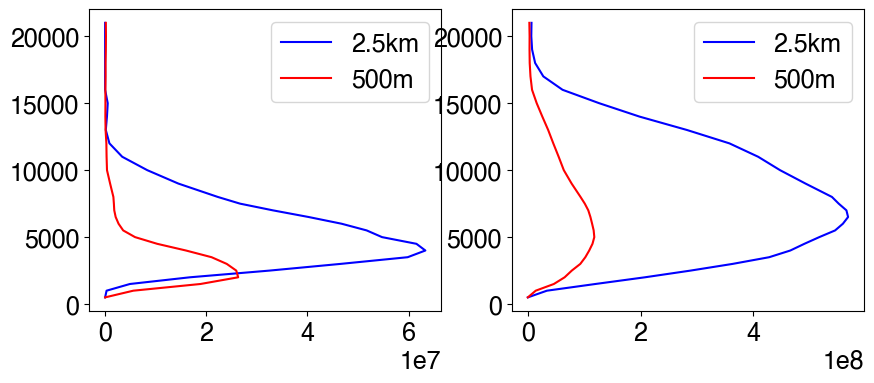

In [25]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
# plt.plot(MaxCoreAreaUp_avg_l_d3, ht_w_d3, 'b', label='narrow')
# plt.plot(MaxCoreAreaUp_avg_h_d3, ht_w_d3, 'r', label='wide')
# plt.plot(MaxMeanWUp_avg_l_d3, ht_w_d3, 'b', label='narrow')
# plt.plot(MaxMeanWUp_avg_h_d3, ht_w_d3, 'r', label='wide')
ax.plot(MaxMassFluxUp_avg_l_d2, ht_w_d3, 'b', label='2.5km')
ax.plot(MaxMassFluxUp_avg_l_d3, ht_w_d2, 'r', label='500m')
ax.legend()

ax = axes[1]
# plt.plot(MaxCoreAreaUp_avg_l_d2, ht_w_d2, 'b', label='narrow')
# plt.plot(MaxCoreAreaUp_avg_h_d2, ht_w_d2, 'r', label='wide')
# plt.plot(MaxMeanWUp_avg_l_d2, ht_w_d2, 'b', label='narrow')
# plt.plot(MaxMeanWUp_avg_h_d2, ht_w_d2, 'r', label='wide')
ax.plot(MaxMassFluxUp_avg_h_d2, ht_w_d2, 'b', label='2.5km')
ax.plot(MaxMassFluxUp_avg_h_d3, ht_w_d3, 'r', label='500m')
ax.legend()

In [26]:
quantiles = [0.25, 0.5, 0.75, 0.9]
MaxCoreAreaUp_qntl_l_d2 = ds_d2.CoreArea_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d2).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()
MaxCoreAreaUp_qntl_h_d2 = ds_d2.CoreArea_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d2).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()

MaxMeanWUp_qntl_l_d2 = ds_d2.CoreMeanW_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d2).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()
MaxMeanWUp_qntl_h_d2 = ds_d2.CoreMeanW_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d2).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()

MaxMassFluxUp_qntl_l_d2 = ds_d2.MassFlux_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d2).max(dim=('times')).quantile(quantiles, dim='tracks').load()
MaxMassFluxUp_qntl_h_d2 = ds_d2.MassFlux_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d2).max(dim=('times')).quantile(quantiles, dim='tracks').load()

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

In [27]:
MaxCoreAreaUp_qntl_l_d3 = ds_d3.CoreArea_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d3).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()
MaxCoreAreaUp_qntl_h_d3 = ds_d3.CoreArea_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d3).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()

MaxMeanWUp_qntl_l_d3 = ds_d3.CoreMeanW_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d3).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()
MaxMeanWUp_qntl_h_d3 = ds_d3.CoreMeanW_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d3).max(dim=('times','core')).quantile(quantiles, dim='tracks').load()

MaxMassFluxUp_qntl_l_d3 = ds_d3.MassFlux_up.chunk(dict(tracks=-1)).isel(tracks=l_idx_d3).max(dim=('times')).quantile(quantiles, dim='tracks').load()
MaxMassFluxUp_qntl_h_d3 = ds_d3.MassFlux_up.chunk(dict(tracks=-1)).isel(tracks=h_idx_d3).max(dim=('times')).quantile(quantiles, dim='tracks').load()

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1584: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/dask/array/reductions.py:608: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, ax

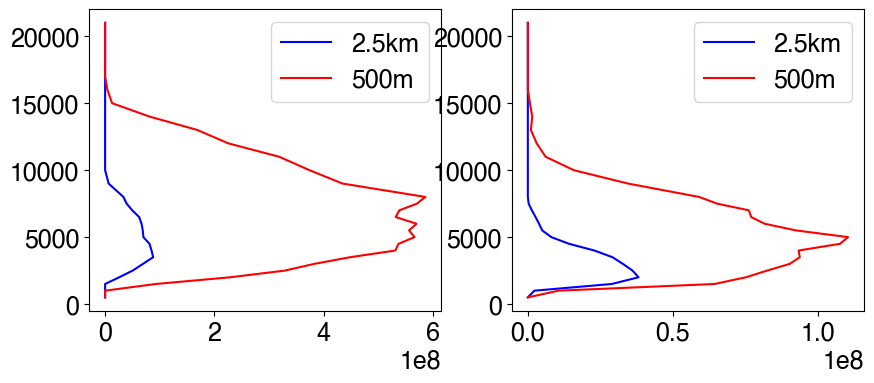

In [28]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
# plt.plot(MaxCoreAreaUp_qntl_l_d2.sel(quantile=0.75), ht_w_d2, 'b', label='narrow')
# plt.plot(MaxCoreAreaUp_qntl_h_d2.sel(quantile=0.75), ht_w_d2, 'r', label='wide')
# plt.plot(MaxMeanWUp_qntl_l_d2.sel(quantile=0.75), ht_w_d2, 'b', label='narrow')
# plt.plot(MaxMeanWUp_qntl_h_d2.sel(quantile=0.75), ht_w_d2, 'r', label='wide')
ax.plot(MaxMassFluxUp_qntl_l_d2.sel(quantile=0.75), ht_w_d2, 'b', label='2.5km')
ax.plot(MaxMassFluxUp_qntl_h_d2.sel(quantile=0.75), ht_w_d2, 'r', label='500m')
ax.legend()

ax = axes[1]
# plt.plot(MaxCoreAreaUp_qntl_l_d3.sel(quantile=0.75), ht_w_d3, 'b', label='narrow')
# plt.plot(MaxCoreAreaUp_qntl_h_d3.sel(quantile=0.75), ht_w_d3, 'r', label='wide')
# plt.plot(MaxMeanWUp_qntl_l_d3.sel(quantile=0.75), ht_w_d3, 'b', label='narrow')
# plt.plot(MaxMeanWUp_qntl_h_d3.sel(quantile=0.75), ht_w_d3, 'r', label='wide')
ax.plot(MaxMassFluxUp_qntl_l_d3.sel(quantile=0.75), ht_w_d3, 'b', label='2.5km')
ax.plot(MaxMassFluxUp_qntl_h_d3.sel(quantile=0.75), ht_w_d3, 'r', label='500m')
ax.legend()

In [29]:
def plot_profiles(ncol, qntl1, qntl2, height, figname, 
                  xlabels=None, ylabels=None, titles=None, xlims=None, ylims=None, 
                  Htline=None, figsize=[10,6]):

    mpl.rcParams['font.size'] = 16
    mpl.rcParams['font.family'] = 'Helvetica'
    lw = 3
    colors = {'d2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
    labels = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}

    fig, axes = plt.subplots(1, ncol, figsize=figsize, dpi=100)

    for col in range(ncol):
        ax = axes[col]
        # ax.plot(MaxCoreAreaUp_avg_l_d2, ht_w_d2/1000, color=colors['d2'], lw=lw, label=labels['d2'])
        # ax.plot(MaxCoreAreaUp_avg_l_d3, ht_w_d3/1000, color=colors['d3'], lw=lw, label=labels['d3'])
        ax.plot(qntl1[col].sel(quantile=0.5), height, color=colors['d2'], lw=lw, label=labels['d2'])
        ax.plot(qntl2[col].sel(quantile=0.5), height, color=colors['d3'], lw=lw, label=labels['d3'])
        ax.fill_betweenx(height, qntl1[col].sel(quantile=0.25), qntl1[col].sel(quantile=0.75), facecolor=colors['d2'], alpha=0.5)
        ax.fill_betweenx(height, qntl2[col].sel(quantile=0.25), qntl2[col].sel(quantile=0.75), facecolor=colors['d3'], alpha=0.5)
        ax.set_xlim(xlims[col][0], xlims[col][1])
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_xlabel(xlabels)
        ax.set_ylabel(ylabels)
        ax.set_title(titles[col], loc='left')
        ax.grid(ls='--')
        ax.legend(loc='best')
        if Htline is not None:
            ax.axhline(y=Htline, color='k', ls='--', lw=lw/2)

    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

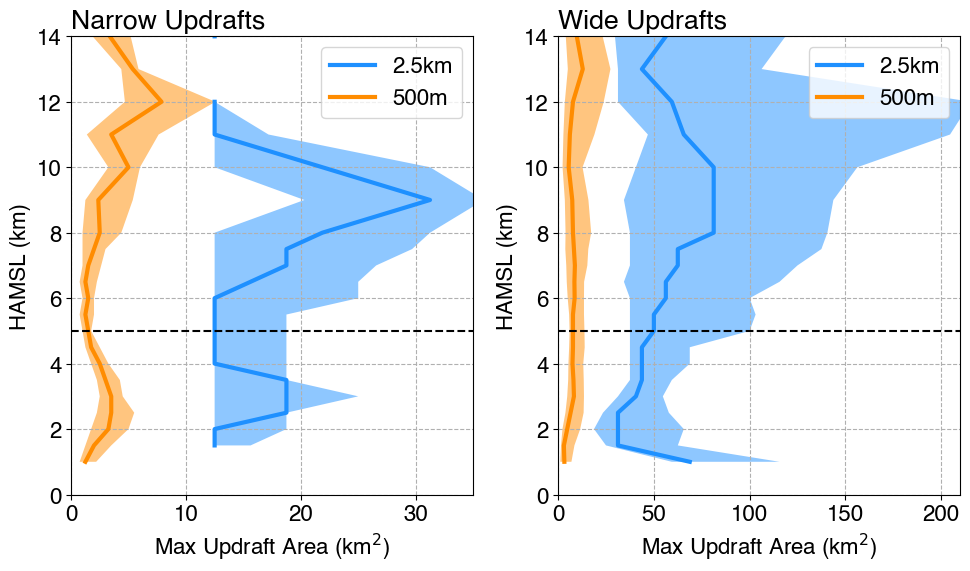

In [30]:
data1_qntl = [MaxCoreAreaUp_qntl_l_d2, MaxCoreAreaUp_qntl_h_d2,]
data2_qntl = [MaxCoreAreaUp_qntl_l_d3, MaxCoreAreaUp_qntl_h_d3,]
height = ht_w_d2/1000
xlabels = 'Max Updraft Area (km$^2$)'
ylabels = 'HAMSL (km)'
titles = ['Narrow Updrafts','Wide Updrafts']
xlims = [(0, 35), (0,210)]
ylims = (0, 14)
figname = f'{figdir}MaxCoreAreaUp_low_high_UpdraftArea{Zmid}km.png'
fig = plot_profiles(2, data1_qntl, data2_qntl, height, figname, 
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, 
                    Htline=Zmid, figsize=[10,6])

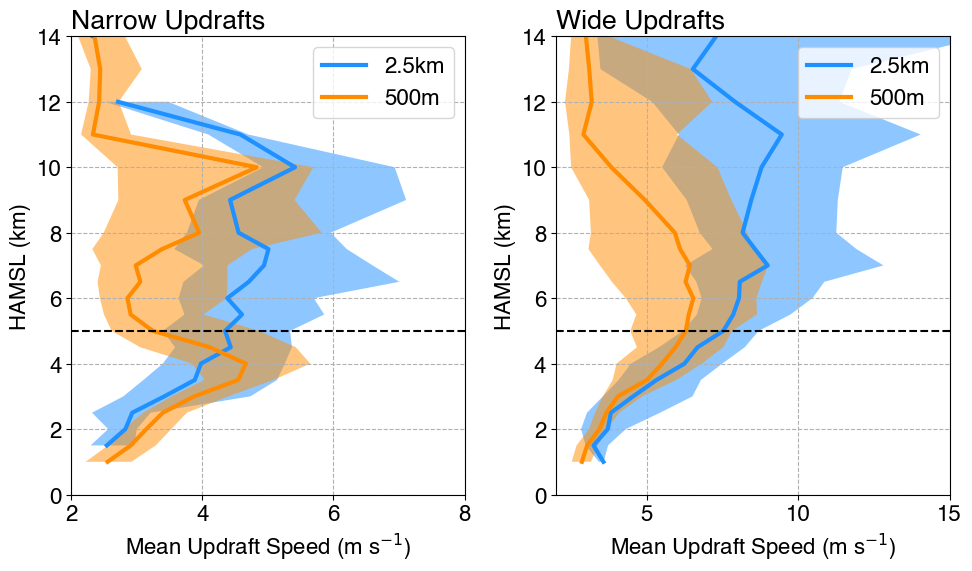

In [31]:
data1_qntl = [MaxMeanWUp_qntl_l_d2, MaxMeanWUp_qntl_h_d2,]
data2_qntl = [MaxMeanWUp_qntl_l_d3, MaxMeanWUp_qntl_h_d3,]
height = ht_w_d2/1000
xlabels = 'Mean Updraft Speed (m s$^{-1}$)'
ylabels = 'HAMSL (km)'
titles = ['Narrow Updrafts','Wide Updrafts']
xlims = [(2, 8), (2, 15)]
ylims = (0, 14)
figname = f'{figdir}MaxMeanWUp_low_high_UpdraftArea{Zmid}km.png'
fig = plot_profiles(2, data1_qntl, data2_qntl, height, figname, 
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, 
                    Htline=Zmid, figsize=[10,6])

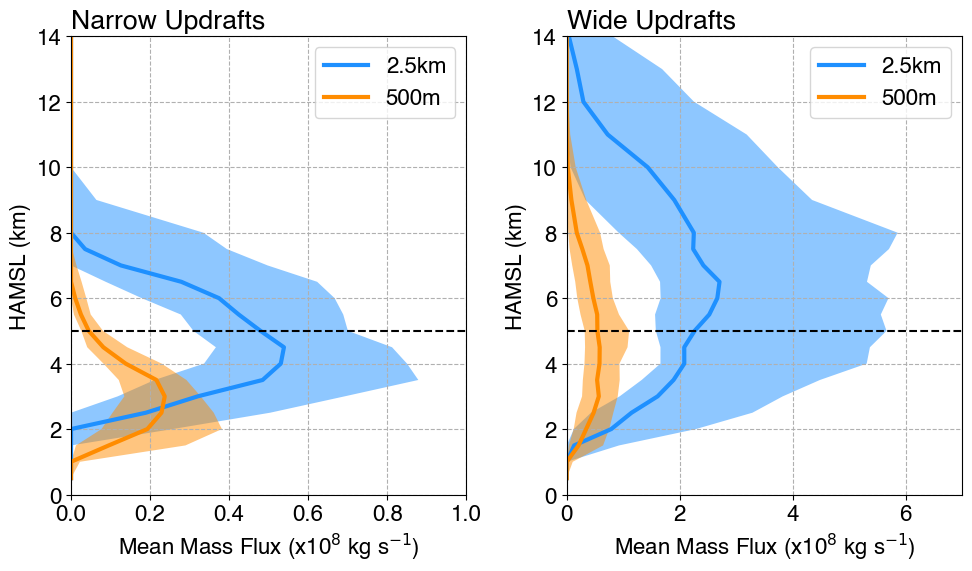

In [32]:
MFpower = 8
MFscale = 10**MFpower
data1_qntl = [MaxMassFluxUp_qntl_l_d2/MFscale, MaxMassFluxUp_qntl_h_d2/MFscale,]
data2_qntl = [MaxMassFluxUp_qntl_l_d3/MFscale, MaxMassFluxUp_qntl_h_d3/MFscale,]
height = ht_w_d2/1000
xlabels = f'Mean Mass Flux (x10$^{MFpower}$'+' kg s$^{-1}$)'
ylabels = 'HAMSL (km)'
titles = ['Narrow Updrafts','Wide Updrafts']
xlims = [(0, 1), (0,7)]
ylims = (0, 14)
figname = f'{figdir}MaxMassFluxUp_low_high_UpdraftArea{Zmid}km.png'
fig = plot_profiles(2, data1_qntl, data2_qntl, height, figname, 
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, 
                    Htline=Zmid, figsize=[10,6])

In [33]:
# Subset RH by tracks, keep preCI times, and composite
rh_l_d2 = ds_d2.rh.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
rh_h_d2 = ds_d2.rh.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
rh_diff_d2 = rh_h_d2 - rh_l_d2

# Time coordinate
xtimes = rh_l_d2.times * time_res_d2

In [34]:
# Subset RH by tracks, keep preCI times, and composite
rh_l_d3 = ds_d3.rh.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
rh_h_d3 = ds_d3.rh.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
rh_diff_d3 = rh_h_d3 - rh_l_d3

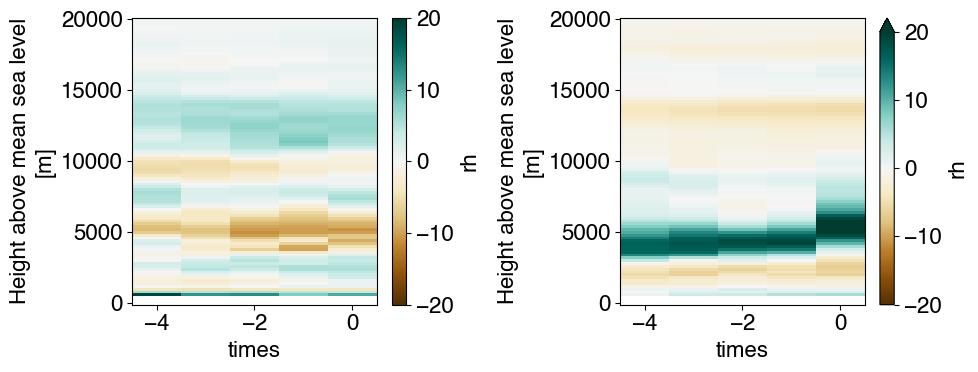

In [35]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
(rh_h_d2 - rh_l_d2).plot(vmin=-20, vmax=20, cmap='BrBG', ax=ax)
ax = axes[1]
(rh_h_d3 - rh_l_d3).plot(vmin=-20, vmax=20, cmap='BrBG', ax=ax)
fig.tight_layout()

In [36]:
# Subset Qv by tracks, keep preCI times, and composite
qv_l_d2 = ds_d2.qv.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
qv_h_d2 = ds_d2.qv.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
qv_diff_d2 = qv_h_d2 - qv_l_d2

In [37]:
# Subset Qv by tracks, keep preCI times, and composite
qv_l_d3 = ds_d3.qv.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
qv_h_d3 = ds_d3.qv.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
qv_diff_d3 = qv_h_d3 - qv_l_d3

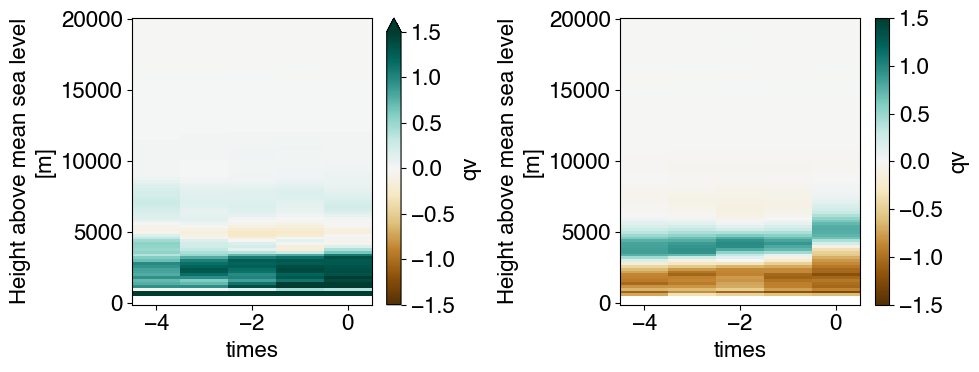

In [38]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
(1000*(qv_h_d2 - qv_l_d2)).plot(vmin=-1.5, vmax=1.5, cmap='BrBG', ax=ax)
ax = axes[1]
(1000*(qv_h_d3 - qv_l_d3)).plot(vmin=-1.5, vmax=1.5, cmap='BrBG', ax=ax)
fig.tight_layout()

In [39]:
# Subset Qv by tracks, keep preCI times, and composite
tk_l_d2 = ds_d2.temperature.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
tk_h_d2 = ds_d2.temperature.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
tk_diff_d2 = tk_h_d2 - tk_l_d2

In [40]:
# Subset Qv by tracks, keep preCI times, and composite
tk_l_d3 = ds_d3.temperature.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
tk_h_d3 = ds_d3.temperature.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
tk_diff_d3 = tk_h_d3 - tk_l_d3

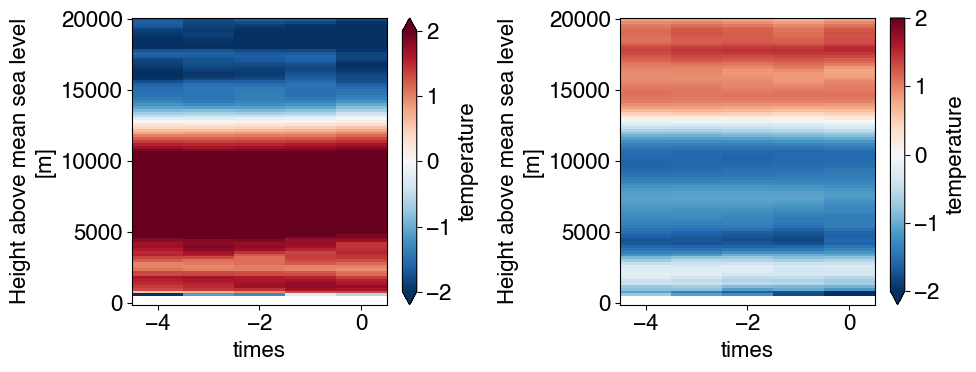

In [41]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
(tk_diff_d2).plot(vmin=-2, vmax=2, cmap='RdBu_r', ax=ax)
ax = axes[1]
(tk_diff_d3).plot(vmin=-2, vmax=2, cmap='RdBu_r', ax=ax)
fig.tight_layout()

In [42]:
# MUCAPE composite
MUCAPE_avg_l_d3 = ds_d3.MUCAPE.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCAPE_avg_h_d3 = ds_d3.MUCAPE.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCAPE_std_l_d3 = ds_d3.MUCAPE.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).std(dim='tracks').load()
MUCAPE_std_h_d3 = ds_d3.MUCAPE.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).std(dim='tracks').load()
MUCAPE_qntl_l_d3 = ds_d3.MUCAPE.chunk(dict(tracks=-1)).isel(tracks=l_idx_d3).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()
MUCAPE_qntl_h_d3 = ds_d3.MUCAPE.chunk(dict(tracks=-1)).isel(tracks=h_idx_d3).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()

In [43]:
MUCAPE_avg_l_d2 = ds_d2.MUCAPE.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks')
MUCAPE_avg_h_d2 = ds_d2.MUCAPE.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks')
MUCAPE_std_l_d2 = ds_d2.MUCAPE.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).std(dim='tracks')
MUCAPE_std_h_d2 = ds_d2.MUCAPE.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).std(dim='tracks')
MUCAPE_qntl_l_d2 = ds_d2.MUCAPE.chunk(dict(tracks=-1)).isel(tracks=l_idx_d2).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()
MUCAPE_qntl_h_d2 = ds_d2.MUCAPE.chunk(dict(tracks=-1)).isel(tracks=h_idx_d2).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()

In [44]:
MUCIN_avg_l_d3 = ds_d3.MUCIN.isel(tracks=l_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCIN_avg_h_d3 = ds_d3.MUCIN.isel(tracks=h_idx_d3).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCIN_qntl_l_d3 = ds_d3.MUCIN.chunk(dict(tracks=-1)).isel(tracks=l_idx_d3).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()
MUCIN_qntl_h_d3 = ds_d3.MUCIN.chunk(dict(tracks=-1)).isel(tracks=h_idx_d3).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()

In [45]:
MUCIN_avg_l_d2 = ds_d2.MUCIN.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCIN_avg_h_d2 = ds_d2.MUCIN.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').load()
MUCIN_qntl_l_d2 = ds_d2.MUCIN.chunk(dict(tracks=-1)).isel(tracks=l_idx_d2).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()
MUCIN_qntl_h_d2 = ds_d2.MUCIN.chunk(dict(tracks=-1)).isel(tracks=h_idx_d2).sel(times=slice(-4,0)).quantile(quantiles, dim='tracks').load()

In [46]:
def plot_Nlines(ncol, avg1, avg2, qntl1, qntl2, xtimes, figname, 
                  xlabels=None, ylabels=None, titles=None, xlims=None, ylims=None, 
                  Htline=None, legend_locs=None, figsize=[10,4]):
    mpl.rcParams['font.size'] = 16
    mpl.rcParams['font.family'] = 'Helvetica'
    lw = 3
    colors = {'d2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
    labels = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
    # ylims = (800,6500)
    # xlabels = 
    fig, axes = plt.subplots(1, ncol, figsize=figsize, dpi=100)

    for col in range(ncol):
        ax = axes[col]
        ax.errorbar(xtimes+0.01, avg1[col], yerr=[qntl1[col].sel(quantile=0.25),qntl1[col].sel(quantile=0.75)], 
                    color=colors['d2'], lw=lw,  marker='o', capsize=5, label=labels['d2'])
        ax.errorbar(xtimes-0.01, avg2[col], yerr=[qntl2[col].sel(quantile=0.25),qntl2[col].sel(quantile=0.75)], 
                    color=colors['d3'], lw=lw, marker='o', capsize=5, label=labels['d3'])
        # ax.set_xlim(xlims[col][0], xlims[col][1])
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_xlabel(xlabels)
        ax.set_ylabel(ylabels[col])
        ax.set_title(titles[col], loc='left')
        ax.grid(ls='--')
        ax.legend(loc=legend_locs[col])

    # ax = axes[1]
    # ax.errorbar(xtimes+0.01, MUCAPE_avg_h_d2, yerr=[MUCAPE_qntl_h_d2.sel(quantile=0.25),MUCAPE_qntl_h_d2.sel(quantile=0.75)], 
    #             color=colors['d2'], lw=lw,  marker='o', capsize=5, label=labels['d2'])
    # ax.errorbar(xtimes-0.01, MUCAPE_avg_h_d3, yerr=[MUCAPE_qntl_h_d3.sel(quantile=0.25),MUCAPE_qntl_h_d3.sel(quantile=0.75)], 
    #             color=colors['d3'], lw=lw, marker='o', capsize=5, label=labels['d3'])
    fig.tight_layout()
    return fig

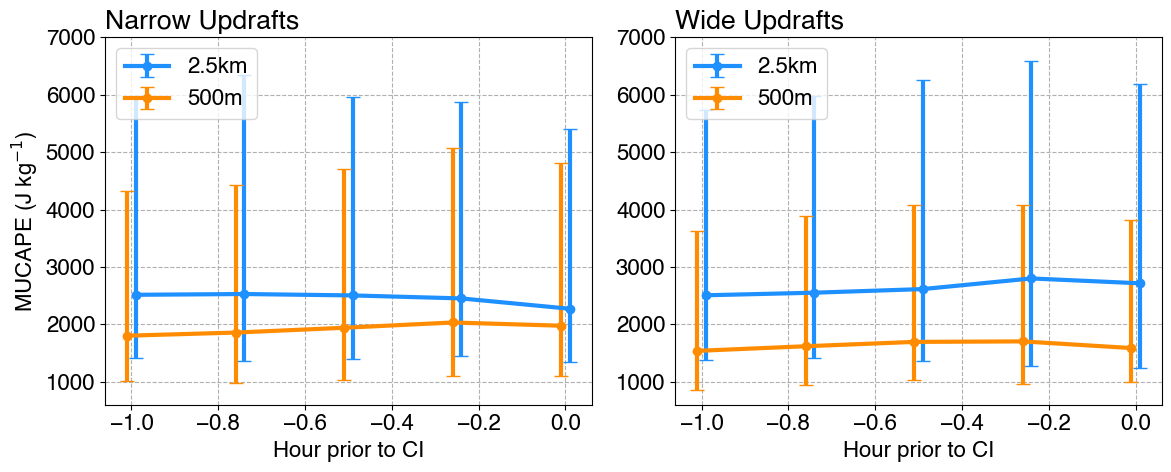

In [47]:
data1_avg = [MUCAPE_avg_l_d2, MUCAPE_avg_h_d2]
data2_avg = [MUCAPE_avg_l_d3, MUCAPE_avg_h_d3]
data1_qntl = [MUCAPE_qntl_l_d2, MUCAPE_qntl_h_d2]
data2_qntl = [MUCAPE_qntl_l_d3, MUCAPE_qntl_h_d3,]
height = ht_w_d2/1000
xlabels = 'Hour prior to CI'
ylabels = ['MUCAPE (J kg$^{-1}$)','']
titles = ['Narrow Updrafts','Wide Updrafts']
# xlims = [(0, 1), (0,7)]
ylims = (600, 7000)
legend_locs = ['upper left', 'upper left']
figname = f'{figdir}PreCI_MUCAPE_low_high_UpdraftArea{Zmid}km.png'
fig = plot_Nlines(2, data1_avg, data2_avg, data1_qntl, data2_qntl, xtimes, figname, 
                    xlabels=xlabels, ylabels=ylabels, titles=titles, xlims=xlims, ylims=ylims, 
                    Htline=Zmid, legend_locs=legend_locs, figsize=[12,5])

In [51]:
# mpl.rcParams['font.size'] = 16
# mpl.rcParams['font.family'] = 'Helvetica'
# lw = 3
# colors = {'d2':'dodgerblue', 'd3':'darkorange', 'd4':'orangered'}
# labels = {'d2':'2.5km', 'd3':'500m', 'd4':'100m'}
# ylims = (800,6500)
# xlabels = 'Hour prior to CI'
# # fig, axes = plt.subplots(1, ncol, figsize=figsize, dpi=100)

# fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
# ax = axes[0]
# ax.errorbar(xtimes+0.01, MUCAPE_avg_l_d2, yerr=[MUCAPE_qntl_l_d2.sel(quantile=0.25),MUCAPE_qntl_l_d2.sel(quantile=0.75)], 
#             color=colors['d2'], lw=lw,  marker='o', capsize=5, label=labels['d2'])
# ax.errorbar(xtimes-0.01, MUCAPE_avg_l_d3, yerr=[MUCAPE_qntl_l_d3.sel(quantile=0.25),MUCAPE_qntl_l_d3.sel(quantile=0.75)], 
#             color=colors['d3'], lw=lw, marker='o', capsize=5, label=labels['d3'])
# # ax.set_xlim(xlims[col][0], xlims[col][1])
# ax.set_ylim(ylims[0], ylims[1])
# ax.set_xlabel(xlabels)
# ax.set_ylabel(ylabels)
# ax.set_title(titles[col], loc='left')
# ax.grid(ls='--')
# ax.legend(loc='best')
# ax.legend()

# ax = axes[1]
# ax.errorbar(xtimes+0.01, MUCAPE_avg_h_d2, yerr=[MUCAPE_qntl_h_d2.sel(quantile=0.25),MUCAPE_qntl_h_d2.sel(quantile=0.75)], 
#             color=colors['d2'], lw=lw,  marker='o', capsize=5, label=labels['d2'])
# ax.errorbar(xtimes-0.01, MUCAPE_avg_h_d3, yerr=[MUCAPE_qntl_h_d3.sel(quantile=0.25),MUCAPE_qntl_h_d3.sel(quantile=0.75)], 
#             color=colors['d3'], lw=lw, marker='o', capsize=5, label=labels['d3'])
# fig.tight_layout()

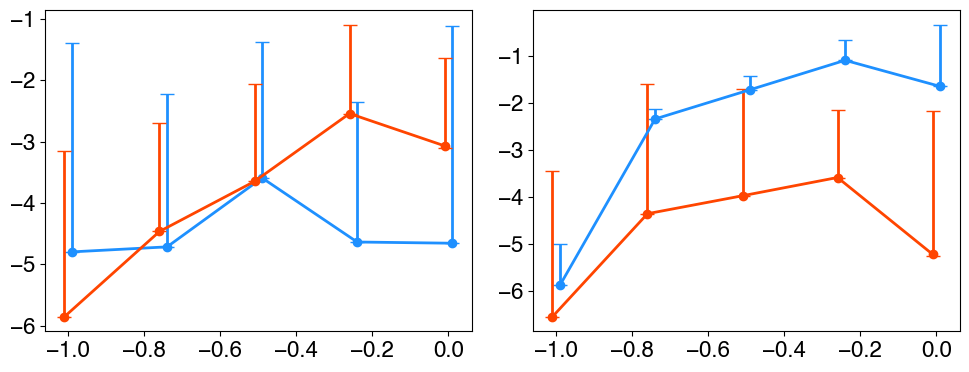

In [52]:
fig, axes = plt.subplots(1, 2, figsize=[10,4], dpi=100)
ax = axes[0]
ax.errorbar(xtimes+0.01, MUCIN_avg_l_d2, yerr=[MUCIN_qntl_l_d2.sel(quantile=0.25),MUCIN_qntl_l_d2.sel(quantile=0.75)], 
            color='dodgerblue', lw=2,  marker='o', capsize=5, label='2.5km')
ax.errorbar(xtimes-0.01, MUCIN_avg_l_d3, yerr=[MUCIN_qntl_l_d3.sel(quantile=0.25),MUCIN_qntl_l_d3.sel(quantile=0.75)], 
            color='orangered', lw=2, marker='o', capsize=5, label='500m')
ax = axes[1]
ax.errorbar(xtimes+0.01, MUCIN_avg_h_d2, yerr=[MUCIN_qntl_h_d2.sel(quantile=0.25),MUCIN_qntl_h_d2.sel(quantile=0.75)], 
            color='dodgerblue', lw=2,  marker='o', capsize=5, label='2.5km')
ax.errorbar(xtimes-0.01, MUCIN_avg_h_d3, yerr=[MUCIN_qntl_h_d3.sel(quantile=0.25),MUCIN_qntl_h_d3.sel(quantile=0.75)], 
            color='orangered', lw=2, marker='o', capsize=5, label='500m')
fig.tight_layout()

In [53]:
figdir

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

In [54]:
# Subset Qv by tracks, keep preCI times, and composite
w_l_d2 = ds_d2.w.isel(tracks=l_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
w_h_d2 = ds_d2.w.isel(tracks=h_idx_d2).sel(times=slice(-4,0)).mean(dim='tracks').transpose()
# Difference between high and low
w_diff_d2 = w_h_d2 - w_l_d2

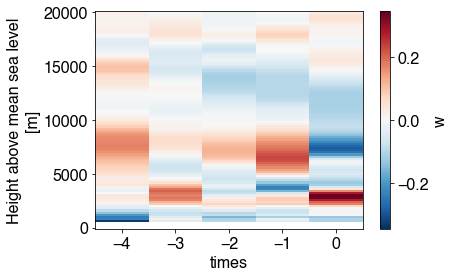

In [55]:
w_diff_d2.plot()

In [56]:
def plot_Npanels(nrow, xx, yy, data_arr, levels, cmaps, cblabels, titles, figname, 
                 xlabels=None, ylabels=None, ylims=(0.5, 15), cbticks=None, oob_colors=None, figsize=[10,4],
                 legends=None, Htline=None):
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['font.family'] = 'Helvetica'
    lw = 2
    
    fig, axes = plt.subplots(1, nrow, figsize=figsize, dpi=100)

    for pp in range(nrow):
        ax = axes[pp]
        cmap = copy.copy(mpl.cm.get_cmap(cmaps[pp]))
        norm = mpl.colors.BoundaryNorm(boundaries=levels[pp], ncolors=cmap.N)
        pcm = ax.pcolormesh(xx, yy, data_arr[pp], norm=norm, cmap=cmap)
        ax.set_ylim(ylims[0], ylims[1])
        ax.set_xlabel(xlabels[pp])
        ax.set_ylabel(ylabels[pp])
        ax.set_title(titles[pp], loc='left')
        # Colorbar
        cb = plt.colorbar(pcm, ax=ax, label=cblabels[pp], pad=0.03)
        # Legends
        if legends is not None:
            ax.text(0.03, 0.92, legends[pp], ha='left', transform=ax.transAxes)
        if Htline is not None:
            ax.axhline(y=Htline, color='k', ls='--', lw=lw)
    
    fig.tight_layout()
    # fig.colorbar(p1, ax=axes[:], label=cblabels, ticks=cbticks, pad=0.03)
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    
    return fig

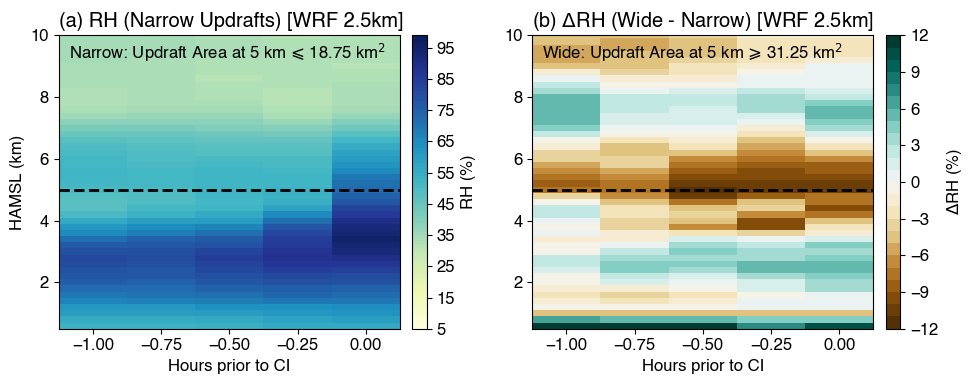

In [63]:
ylims = (0.5, 10)
lev1 = np.arange(5, 100, 1)
lev2 = np.arange(-12, 12.1, 1)
levels = [lev1, lev2]
cmaps = ['YlGnBu','BrBG',]
data_arr = [rh_l_d2, rh_diff_d2,]
cblabels = ['RH (%)', '$\Delta$RH (%)']
cbticks = None
titles = [f'(a) RH (Narrow Updrafts) [WRF 2.5km]',
          f'(b) $\Delta$RH (Wide - Narrow) [WRF 2.5km]']
legends = [f'Narrow: Updraft Area at {Zmid} km $\leqslant$ {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$',
           f'Wide: Updraft Area at {Zmid} km $\geqslant$ {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$',]
xlabels = ['Hours prior to CI', 'Hours prior to CI', ]
ylabels = ['HAMSL (km)', '']
figsize = [10, 4]
figname = f'{figdir}PreCI_EnvProf_RH_low_hi_UpdraftArea{Zmid}km_d2.png'
fig = plot_Npanels(2, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
                   xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

In [64]:
# ylims = (0.5, 10)
# lev1 = np.arange(5, 100, 1)
# lev2 = np.arange(-12, 12.1, 1)
# levels = [lev1, lev1, lev2]
# cmaps = ['YlGnBu','YlGnBu','BrBG',]
# data_arr = [rh_l_d2, rh_h_d2, rh_diff_d2,]
# cblabels = ['RH (%)', 'RH (%)', '$\Delta$RH (%)']
# cbticks = None
# titles = [f'(a) RH (Narrow Updrafts) [WRF 2.5km]',
#           f'(b) RH (Wide Updrafts) [WRF 2.5km]',
#           f'(c) $\Delta$RH (Wide - Narrow) [WRF 2.5km]']
# legends = [f'Updraft Area @ {Zmid} km (< {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#            f'Updraft Area @ {Zmid} km (> {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#            f'Updraft Area @ {Zmid} km (> {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',]
# xlabels = ['Hours prior to CI', 'Hours prior to CI', 'Hours prior to CI', ]
# ylabels = ['HAMSL (km)', '', '']
# figsize = [14, 4]
# figname = f'{figdir}PreCI_EnvProf_RH_low_hi_UpdraftArea{Zmid}km_d2.png'
# fig = plot_Npanels(3, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

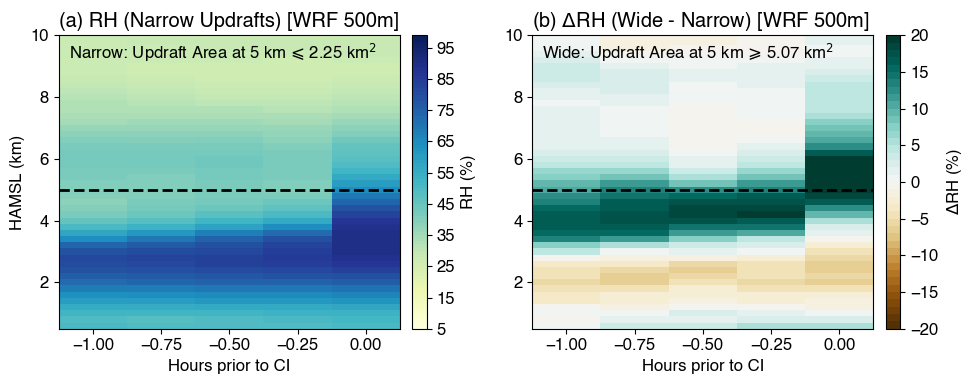

In [68]:
lev1 = np.arange(5, 100, 1)
lev2 = np.arange(-20, 20.1, 1)
levels = [lev1, lev2]
cmaps = ['YlGnBu','BrBG',]
data_arr = [rh_l_d3, rh_diff_d3,]
cblabels = ['RH (%)', '$\Delta$RH (%)']
cbticks = None
titles = [f'(a) RH (Narrow Updrafts) [WRF 500m]',
          f'(b) $\Delta$RH (Wide - Narrow) [WRF 500m]']
legends = [f'Narrow: Updraft Area at {Zmid} km $\leqslant$ {low_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$',
           f'Wide: Updraft Area at {Zmid} km $\geqslant$ {hi_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$',]
xlabels = ['Hours prior to CI', 'Hours prior to CI', ]
ylabels = ['HAMSL (km)', '']
figsize = [10, 4]
figname = f'{figdir}PreCI_EnvProf_RH_low_hi_UpdraftArea{Zmid}km_d3.png'
fig = plot_Npanels(2, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
                   xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

In [69]:
# lev1 = np.arange(5, 100, 1)
# lev2 = np.arange(-20, 20.1, 1)
# levels = [lev1, lev1, lev2]
# cmaps = ['YlGnBu','YlGnBu','BrBG',]
# data_arr = [rh_l_d3, rh_h_d3, rh_diff_d3,]
# cblabels = ['RH (%)', 'RH (%)', '$\Delta$RH (%)']
# cbticks = None
# titles = [f'(a) RH (Narrow Updrafts) [WRF 500m]',
#           f'(b) RH (Wide Updrafts) [WRF 500m]',
#           f'(c) $\Delta$RH (Wide - Narrow) [WRF 500m]']
# legends = [f'Updraft Area @ {Zmid} km (< {low_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$)',
#            f'Updraft Area @ {Zmid} km (> {hi_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$)',
#            '']
# xlabels = ['Hours prior to CI', 'Hours prior to CI', 'Hours prior to CI', ]
# ylabels = ['HAMSL (km)', '', '']
# figsize = [14, 4]
# figname = f'{figdir}PreCI_EnvProf_RH_low_hi_UpdraftArea{Zmid}km_d3.png'
# fig = plot_Npanels(3, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

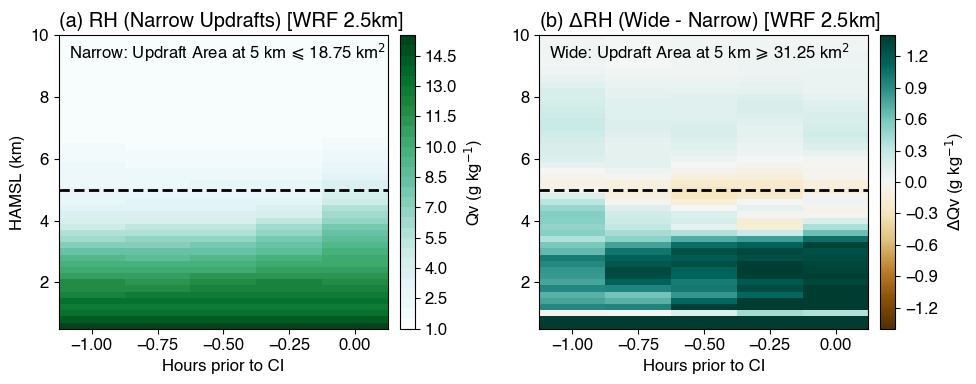

In [70]:
# ylims = (0.5, 14)
lev1 = np.arange(1, 16, 0.5)
lev2 = np.arange(-1.4, 1.41, 0.02)
levels = [lev1, lev2]
cmaps = ['BuGn','BrBG',]
data_arr = [1000*qv_l_d2, 1000*qv_diff_d2,]
cblabels = ['Qv (g kg$^{-1}$)', '$\Delta$Qv (g kg$^{-1}$)']
cbticks = None
titles = [f'(a) RH (Narrow Updrafts) [WRF 2.5km]',
          f'(b) $\Delta$RH (Wide - Narrow) [WRF 2.5km]']
legends = [f'Narrow: Updraft Area at {Zmid} km $\leqslant$ {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$',
           f'Wide: Updraft Area at {Zmid} km $\geqslant$ {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$',]
xlabels = ['Hours prior to CI', 'Hours prior to CI', ]
ylabels = ['HAMSL (km)', '',]
figsize = [10, 4]
figname = f'{figdir}PreCI_EnvProf_Qv_low_hi_UpdraftArea{Zmid}km_d2.png'
fig = plot_Npanels(2, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
                   xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

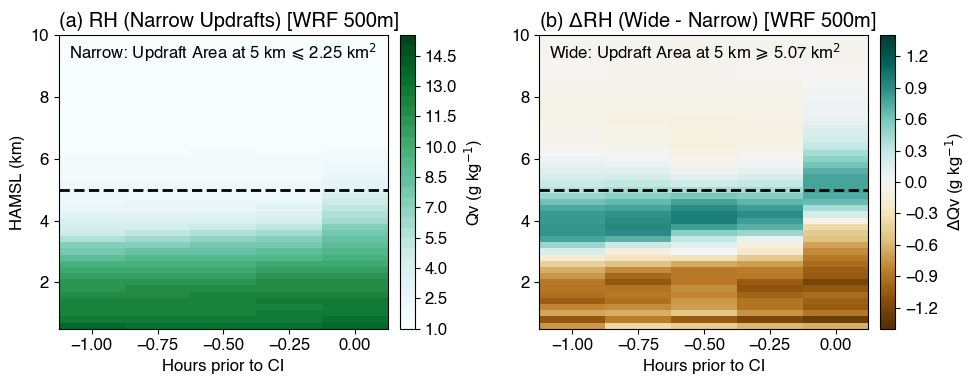

In [71]:
lev1 = np.arange(1, 16, 0.5)
lev2 = np.arange(-1.4, 1.41, 0.02)
levels = [lev1, lev2]
cmaps = ['BuGn','BrBG',]
data_arr = [1000*qv_l_d3, 1000*qv_diff_d3,]
cblabels = ['Qv (g kg$^{-1}$)', '$\Delta$Qv (g kg$^{-1}$)']
cbticks = None
titles = [f'(a) RH (Narrow Updrafts) [WRF 500m]',
          f'(b) $\Delta$RH (Wide - Narrow) [WRF 500m]']
legends = [f'Narrow: Updraft Area at {Zmid} km $\leqslant$ {low_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$',
           f'Wide: Updraft Area at {Zmid} km $\geqslant$ {hi_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$',]
xlabels = ['Hours prior to CI', 'Hours prior to CI', ]
ylabels = ['HAMSL (km)', '', ]
figsize = [10, 4]
figname = f'{figdir}PreCI_EnvProf_Qv_low_hi_UpdraftArea{Zmid}km_d3.png'
fig = plot_Npanels(2, xtimes, ht_e_d3/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
                   xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

In [74]:
figdir

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

In [72]:
# # ylims = (0.5, 14)
# lev1 = np.arange(1, 16, 0.5)
# lev2 = np.arange(-1.4, 1.41, 0.02)
# levels = [lev1, lev1, lev2]
# cmaps = ['BuGn','BuGn','BrBG',]
# data_arr = [1000*qv_l_d2, 1000*qv_h_d2, 1000*qv_diff_d2,]
# cblabels = ['Qv (g kg$^{-1}$)', 'Qv (g kg$^{-1}$)', '$\Delta$Qv (g kg$^{-1}$)']
# cbticks = None
# titles = [f'(a) Qv (Narrow Updrafts) [WRF 2.5km]',
#           f'(b) Qv (Wide Updrafts) [WRF 2.5km]',
#           f'(c) $\Delta$Qv (Wide - Narrow) [WRF 2.5km]']
# legends = [f'Updraft Area @ {Zmid} km (< {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#            f'Updraft Area @ {Zmid} km (> {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#            '']
# xlabels = ['Hours prior to CI', 'Hours prior to CI', 'Hours prior to CI', ]
# ylabels = ['HAMSL (km)', '', '']
# figsize = [14, 4]
# figname = f'{figdir}PreCI_EnvProf_Qv_low_hi_UpdraftArea{Zmid}km_d2.png'
# fig = plot_Npanels(3, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

In [73]:
# lev1 = np.arange(1, 16, 0.5)
# lev2 = np.arange(-1.4, 1.41, 0.02)
# levels = [lev1, lev1, lev2]
# cmaps = ['BuGn','BuGn','BrBG',]
# data_arr = [1000*qv_l_d3, 1000*qv_h_d3, 1000*qv_diff_d3,]
# cblabels = ['Qv (g kg$^{-1}$)', 'Qv (g kg$^{-1}$)', '$\Delta$Qv (g kg$^{-1}$)']
# cbticks = None
# titles = [f'(a) Qv (Narrow Updrafts) [WRF 500m]',
#           f'(b) Qv (Wide Updrafts) [WRF 500m]',
#           f'(c) $\Delta$Qv (Wide - Narrow) [WRF 500m]']
# legends = [f'Updraft Area @ {Zmid} km (< {low_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$)',
#            f'Updraft Area @ {Zmid} km (> {hi_MaxCoreAreaUp_Zmid_d3:.02f} km$^2$)',
#            '']
# xlabels = ['Hours prior to CI', 'Hours prior to CI', 'Hours prior to CI', ]
# ylabels = ['HAMSL (km)', '', '']
# figsize = [14, 4]
# figname = f'{figdir}PreCI_EnvProf_Qv_low_hi_UpdraftArea{Zmid}km_d3.png'
# fig = plot_Npanels(3, xtimes, ht_e_d3/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, legends=legends, Htline=Zmid)

In [49]:
# lev1 = np.arange(1, 16, 0.5)
# lev2 = np.arange(-0.8, 0.81, 0.02)
# levels = [lev1, lev1, lev2]
# cmaps = ['BuGn','BuGn','BrBG',]
# data_arr = [1000*qv_l_d2, 1000*qv_h_d2, 1000*qv_diff_d2,]
# cblabels = ['Qv (g kg$^{-1}$)', 'Qv (g kg$^{-1}$)', '$\Delta$Qv (g kg$^{-1}$)']
# cbticks = None
# titles = [f'(a) Updraft Area @ 6 km (< {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#           f'(b) Updraft Area @ 6 km (> {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#           f'(c) Differences (Wide - Narrow)']
# xlabels = ['Hours prior to CI', 'Hours prior to CI', 'Hours prior to CI', ]
# ylabels = ['HAMSL (km)', '', '']
# figsize = [14, 4]
# figname = f'{figdir}PreCI_EnvProf_Qv_low_hi_UpdraftArea6km.png'
# fig = plot_Npanels(3, xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, figsize=figsize, )

In [50]:
# ylims = (0.5, 14)
# levels = np.arange(-25, 25, 1)
# cmaps = 'BrBG'
# data_arr = [rh_l_anom_d2.transpose(), rh_h_anom_d2.transpose()]
# cblabels = 'RH Anomaly (%)'
# cbticks = None
# titles = [f'(a) Updraft Area @ 6 km (< {low_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)',
#           f'(b) Updraft Area @ 6 km (> {hi_MaxCoreAreaUp_Zmid_d2:.02f} km$^2$)']
# xlabels = ['Hours prior to CI', 'Hours prior to CI']
# ylabels = ['HAMSL (km)', '']
# figname = f'{figdir}PreCI_EnvProf_RHanomaly_low_hi_UpdraftArea6km.png'
# fig = plot_2panels(xtimes, ht_e_d2/1000., data_arr, levels, cmaps, cblabels, titles, figname, 
#                    xlabels=xlabels, ylabels=ylabels, ylims=ylims, cbticks=cbticks, )

In [51]:
# fig, axes = plt.subplots(1, 2, figsize=[12,5], dpi=100)
# ylims = (500, 15000)
# # levels = np.arange(10, 91, 1)
# levels = np.arange(-25, 25, 1)
# cmap = copy.copy(mpl.cm.get_cmap('BrBG'))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
# ax = axes[0]
# p1 = ax.pcolormesh(xtimes, ht_e_d2, rh_l_anom_d2.transpose(), norm=norm, cmap=cmap)
# ax.set_ylim(ylims[0], ylims[1])
# ax = axes[1]
# p2 = ax.pcolormesh(xtimes, ht_e_d2, rh_h_anom_d2.transpose(), norm=norm, cmap=cmap)
# ax.set_ylim(ylims[0], ylims[1])
# fig.colorbar(p1, ax=axes[:])

In [52]:
# fig, axes = plt.subplots(1, 2, figsize=[12,5], dpi=100)
# ylims = (500, 15000)
# levels = np.arange(-1.2, 1.2, 0.05)
# cmap = copy.copy(mpl.cm.get_cmap('BrBG'))
# norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
# ax = axes[0]
# p1 = ax.pcolormesh(xtimes, ht_e_d2, 1000*qv_l_anom_d2.transpose(), norm=norm, cmap=cmap)
# ax.set_ylim(ylims[0], ylims[1])
# ax = axes[1]
# p2 = ax.pcolormesh(xtimes, ht_e_d2, 1000*qv_h_anom_d2.transpose(), norm=norm, cmap=cmap)
# ax.set_ylim(ylims[0], ylims[1])
# fig.colorbar(p1, ax=axes[:])